<a href="https://colab.research.google.com/github/Khang-lee/Gradutation-Project/blob/master/Buoi2_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nạp các thư viện xử lý dữ liệu và bảng
import pandas as pd
import numpy as np

# Nạp thư viện trực quan hóa hình ảnh và đồ thị
import matplotlib.pyplot as plt

# Nạp các thư viện chính của TensorFlow và Keras phục vụ ANN
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense

# Nạp thư viện chuẩn hóa dữ liệu từ Scikit-learn
from sklearn.preprocessing import MinMaxScaler

# Các thư viện phục vụ tải và xử lý ảnh thực tế từ máy tính
from google.colab import files
import cv2

print("Đã nạp thành công toàn bộ thư viện!")

Đã nạp thành công toàn bộ thư viện!


In [11]:
import cv2
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# 1. Định nghĩa danh sách tên các nhãn bằng tiếng Việt để hiển thị kết quả
class_names = [
    "Áo thun (T-shirt/top)",
    "Quần dài (Trouser)",
    "Áo len cổ chui (Pullover)",
    "Váy liền (Dress)",
    "Áo khoác (Coat)",
    "Giày sandal (Sandal)",
    "Áo sơ mi (Shirt)",
    "Giày thể thao (Sneaker)",
    "Túi xách (Bag)",
    "Ủng/Bốt (Ankle boot)"
]

# 2. Tải trực tiếp bộ dữ liệu từ thư viện keras (Gốc vẫn là 28x28)
fashion = tf.keras.datasets.fashion_mnist
(X_train_raw, y_train), (X_test_raw, y_test) = fashion.load_data()
print("Kích thước dữ liệu gốc từ thư viện:", X_train_raw.shape)

# CHÈN THÊM BƯỚC THAY ĐỔI KÍCH THƯỚC ẢNH LỚN HƠN TẠI ĐÂY:
KICH_THUOC_MOI = 64  # Bạn có thể đổi thành 64, 128 hoặc 256 tùy ý
SO_THUOC_TINH = KICH_THUOC_MOI * KICH_THUOC_MOI  # 64 * 64 = 4096

print(f"Đang tiến hành phóng to ảnh lên kích thước mới {KICH_THUOC_MOI}x{KICH_THUOC_MOI}...")
# Sử dụng vòng lặp để duyệt qua từng bức ảnh 28x28 và dùng OpenCV (cv2) để phóng to lên 64x64
X_train_resized = np.array([cv2.resize(img, (KICH_THUOC_MOI, KICH_THUOC_MOI)) for img in X_train_raw])
X_test_resized = np.array([cv2.resize(img, (KICH_THUOC_MOI, KICH_THUOC_MOI)) for img in X_test_raw])


# 3. Thay đổi hình dạng dữ liệu (Reshape) từ ma trận 3D sang mảng 2D (Dùng số thuộc tính mới)
# Thay vì duỗi về 784 như ảnh gốc, ta duỗi về kích thước mới (ví dụ 64*64 = 4096)
X_train = X_train_resized.reshape(60000, SO_THUOC_TINH)
X_test = X_test_resized.reshape(10000, SO_THUOC_TINH)


# 4. Sử dụng MinMaxScaler để chuẩn hóa dữ liệu về đoạn [0, 1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print("Kích thước dữ liệu SAU KHI PHÓNG TO và xử lý:", X_train.shape, X_test.shape)
# Màn hình sẽ hiển thị kết quả là: (60000, 4096) (10000, 4096)

Kích thước dữ liệu gốc từ thư viện: (60000, 28, 28)
Đang tiến hành phóng to ảnh lên kích thước mới 64x64...
Kích thước dữ liệu SAU KHI PHÓNG TO và xử lý: (60000, 4096) (10000, 4096)


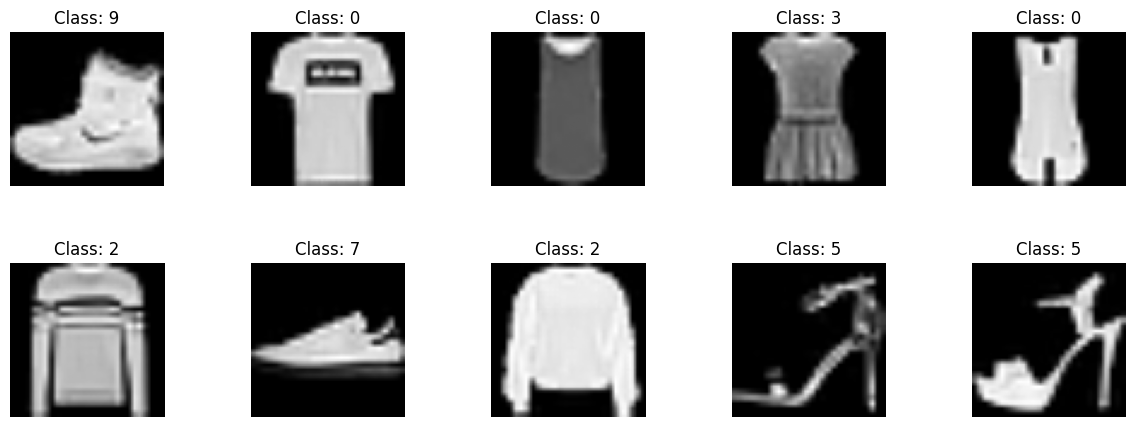

In [ ]:
# Thiết lập lưới đồ thị gồm 2 hàng và 5 cột để vẽ 10 ảnh
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

# Vòng lặp vẽ ảnh và gán nhãn thực tế cho từng ảnh
for i in range(10):
    # ĐÃ SỬA: Đổi từ (28, 28) thành (64, 64) cho khớp với kích thước dữ liệu mới
    ax[i].imshow(X_train[i].reshape(64, 64), cmap='gray')

    ax[i].title.set_text("Class: " + str(y_train[i]))
    ax[i].axis('off') # Ẩn khung tọa độ của ảnh

plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 1. Định nghĩa mô hình ANN phù hợp với ảnh 64x64
fashion_model = Sequential()
fashion_model.add(Input(shape=(4096,)))
fashion_model.add(Dense(256, activation='relu'))
fashion_model.add(Dense(128, activation='relu'))
fashion_model.add(Dense(10, activation='softmax'))

# 2. Biên dịch mô hình
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Tiến hành huấn luyện mô hình
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8137 - loss: 0.5133 - val_accuracy: 0.8588 - val_loss: 0.3840
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8562 - loss: 0.3908 - val_accuracy: 0.8618 - val_loss: 0.3956
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8700 - loss: 0.3555 - val_accuracy: 0.8538 - val_loss: 0.3979
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8773 - loss: 0.3342 - val_accuracy: 0.8575 - val_loss: 0.4054
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8821 - loss: 0.3175 - val_accuracy: 0.8727 - val_loss: 0.3571
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8869 - loss: 0.3048 - val_accuracy: 0.8698 - val_loss: 0.3632
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8899 - loss: 0.2962 - val_accuracy: 0.8822 - val_loss: 0.3298
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8935 - loss: 0.2862 - 

================ KẾT QUẢ ĐÁNH GIÁ TỔNG QUAN ================
-> Độ chính xác trên tập kiểm thử (Test Accuracy): 87.64%
-> Giá trị sai số trên tập kiểm thử (Test Loss)    : 0.3905

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
================ BÁO CÁO PHÂN LỚP CHI TIẾT ================
                           precision    recall  f1-score   support

    Áo thun (T-shirt/top)       0.84      0.79      0.81      1000
       Quần dài (Trouser)       0.99      0.96      0.98      1000
Áo len cổ chui (Pullover)       0.79      0.81      0.80      1000
         Váy liền (Dress)       0.82      0.92      0.87      1000
          Áo khoác (Coat)       0.80      0.82      0.81      1000
     Giày sandal (Sandal)       0.97      0.96      0.97      1000
         Áo sơ mi (Shirt)       0.72      0.66      0.69      1000
  Giày thể thao (Sneaker)       0.89      0.98      0.93      1000
           Túi xách (Bag)       0.97      0.97      0.97      1000
     Ủng/Bốt (Ankle boot)       0.98      0.90  

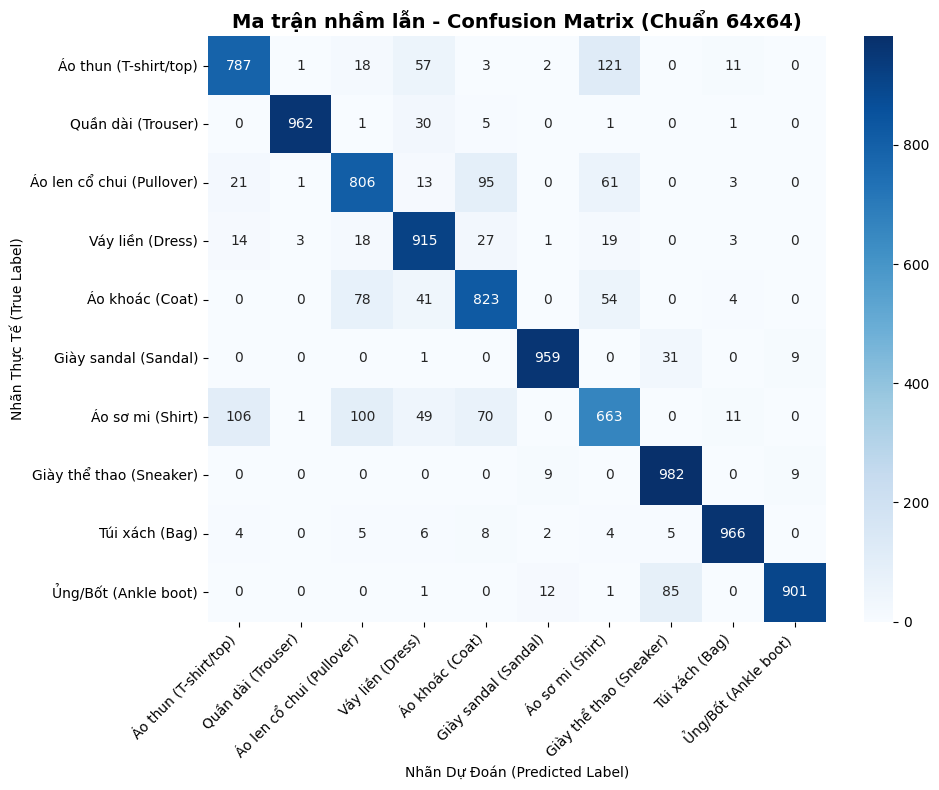

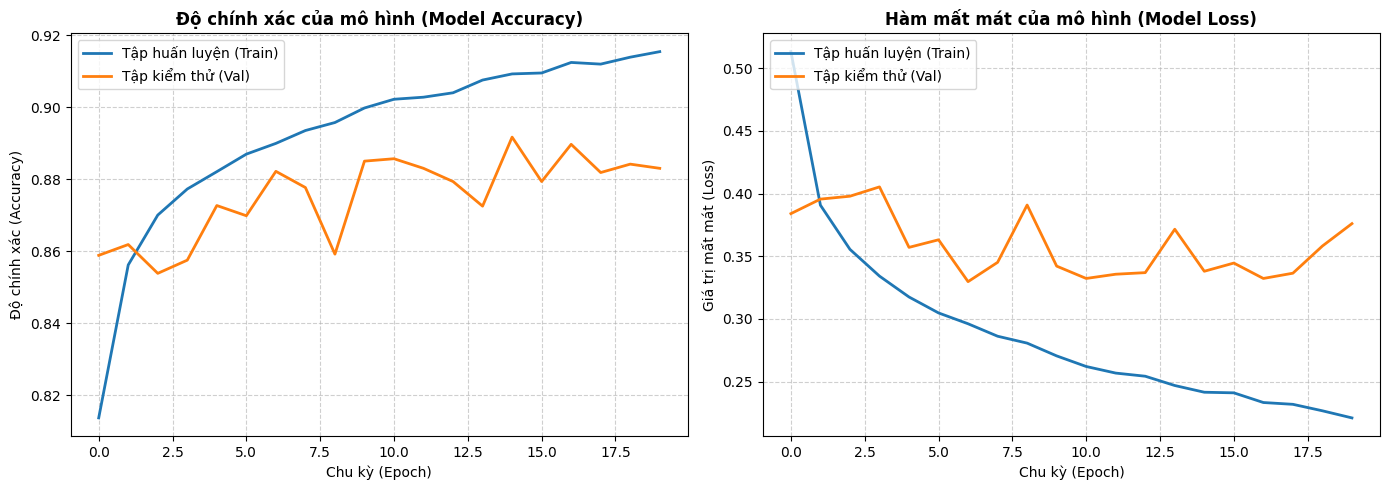

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ĐÁNH GIÁ TỔNG QUAN LOSS & ACCURACY ---
# Đánh giá trên 10,000 bức ảnh kiểm thử độc lập (X_test, y_test) mà mô hình chưa từng thấy
test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)

print("================ KẾT QUẢ ĐÁNH GIÁ TỔNG QUAN ================")
print(f"-> Độ chính xác trên tập kiểm thử (Test Accuracy): {test_accuracy * 100:.2f}%")
print(f"-> Giá trị sai số trên tập kiểm thử (Test Loss)    : {test_loss:.4f}\n")


# --- 2. DỰ ĐOÁN NHÃN CHO TOÀN BỘ TẬP KIỂM THỬ ---
# Máy dự đoán ra xác suất % của 10 lớp cho mỗi bức ảnh
y_pred_probs = fashion_model.predict(X_test)
# Lấy vị trí cột có % cao nhất để chuyển về dạng nhãn số số từ 0 đến 9
y_pred_labels = np.argmax(y_pred_probs, axis=1)


# --- 3. XUẤT BÁO CÁO PHÂN LỚP CHI TIẾT (CLASSIFICATION REPORT) ---
# Trình bày chi tiết chỉ số Precision, Recall, F1-Score của từng loại quần áo
print("================ BÁO CÁO PHÂN LỚP CHI TIẾT ================")
print(classification_report(y_test, y_pred_labels, target_names=class_names))


# --- 4. VẼ BIỂU ĐỒ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
plt.figure(figsize=(10, 8))
# Tính toán ma trận nhầm lẫn giữa nhãn thực tế (y_test) và nhãn dự đoán (y_pred_labels)
cm = confusion_matrix(y_test, y_pred_labels)

# Sử dụng thư viện seaborn để vẽ biểu đồ nhiệt (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Ma trận nhầm lẫn - Confusion Matrix (Chuẩn 64x64)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#BIỂU ĐỒ LOSS VÀ ACCURACY
import matplotlib.pyplot as plt

# Khởi tạo một khung hình lớn chứa cả 2 đồ thị nằm ngang hàng với nhau
plt.figure(figsize=(14, 5))

# --- ĐỒ THỊ 1: ĐỘ CHÍNH XÁC (MODEL ACCURACY) ---
plt.subplot(1, 2, 1) # Vị trí ô số 1 ở bên trái
plt.plot(model_fit.history['accuracy'], label='Tập huấn luyện (Train)', color='#1f77b4', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Tập kiểm thử (Val)', color='#ff7f0e', linewidth=2)
plt.title('Độ chính xác của mô hình (Model Accuracy)', fontsize=12, fontweight='bold')
plt.ylabel('Độ chính xác (Accuracy)')
plt.xlabel('Chu kỳ (Epoch)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới mờ phía sau giống ảnh gốc

# --- ĐỒ THỊ 2: SỰ MẤT MÁT (MODEL LOSS) ---
plt.subplot(1, 2, 2) # Vị trí ô số 2 ở bên phải
plt.plot(model_fit.history['loss'], label='Tập huấn luyện (Train)', color='#1f77b4', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Tập kiểm thử (Val)', color='#ff7f0e', linewidth=2)
plt.title('Hàm mất mát của mô hình (Model Loss)', fontsize=12, fontweight='bold')
plt.ylabel('Giá trị mất mát (Loss)')
plt.xlabel('Chu kỳ (Epoch)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới mờ phía sau giống ảnh gốc

# Căn chỉnh khoảng cách giữa 2 đồ thị để không bị đè chữ
plt.tight_layout()
plt.show()

          TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH HỒI QUY (LOGISTIC REGRESSION)   
---> Đang fit dữ liệu lớn 64x64 vào mô hình Hồi quy... (Vui lòng chờ giây lát)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


max_iter reached after 217 seconds
-> Hoàn thành huấn luyện Hồi quy trong: 218.06 giây.



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  3.6min finished


============ KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC SƠ BỘ ============
-> Độ chính xác trên tập huấn luyện (Train Accuracy): 87.16%
-> Độ chính xác trên tập kiểm thử (Test Accuracy)  : 84.67%

================ BÁO CÁO PHÂN LỚP CHI TIẾT (REGRESSION) ================
                           precision    recall  f1-score   support

    Áo thun (T-shirt/top)       0.81      0.82      0.81      1000
       Quần dài (Trouser)       0.97      0.96      0.97      1000
Áo len cổ chui (Pullover)       0.73      0.74      0.73      1000
         Váy liền (Dress)       0.83      0.87      0.85      1000
          Áo khoác (Coat)       0.74      0.76      0.75      1000
     Giày sandal (Sandal)       0.95      0.92      0.94      1000
         Áo sơ mi (Shirt)       0.64      0.57      0.60      1000
  Giày thể thao (Sneaker)       0.91      0.94      0.92      1000
           Túi xách (Bag)       0.93      0.95      0.94      1000
     Ủng/Bốt (Ankle boot)       0.95      0.94      0.95      1000

    

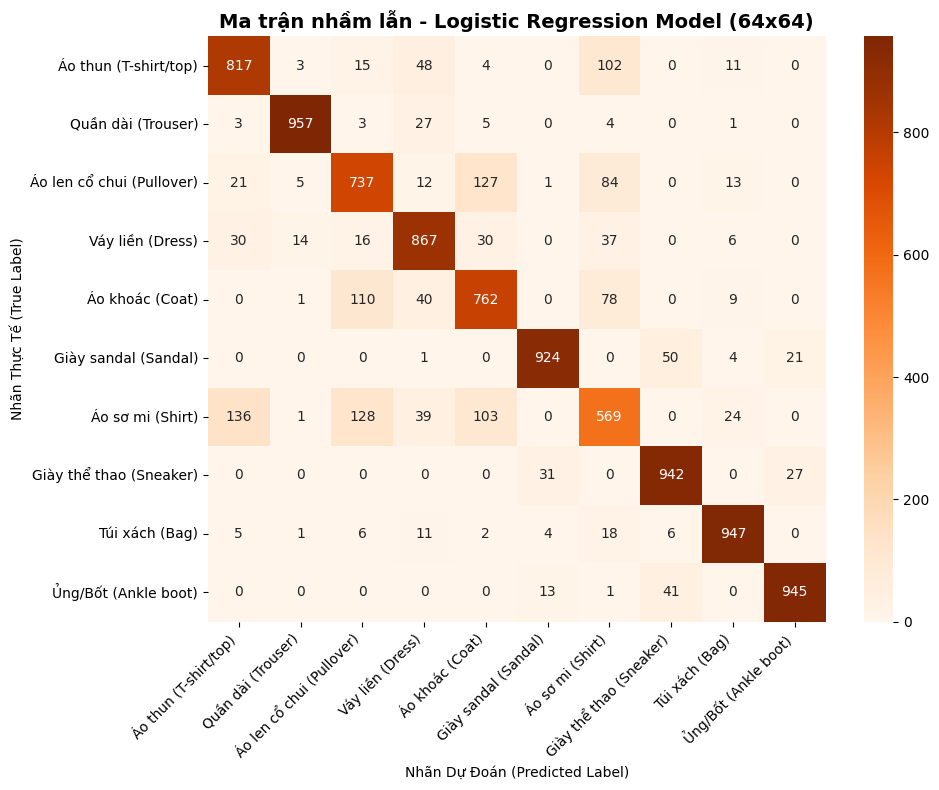

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import time

print("======================================================================")
print("          TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH HỒI QUY (LOGISTIC REGRESSION)   ")
print("======================================================================")

# 1. Khởi tạo mô hình Hồi quy Logistic cho bài toán nhiều lớp (multi_class='multinomial')
# Cấu hình solver='saga' để xử lý tốt dữ liệu lớn 4096 thuộc tính, max_iter=20 để chạy nhanh
regression_model = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=20, verbose=1)

# Đo thời gian huấn luyện của mô hình hồi quy
start_time = time.time()
print("---> Đang fit dữ liệu lớn 64x64 vào mô hình Hồi quy... (Vui lòng chờ giây lát)")
regression_model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"-> Hoàn thành huấn luyện Hồi quy trong: {train_time:.2f} giây.\n")


# 2. ĐÁNH GIÁ ĐỘ CHÍNH XÁC (ACCURACY)
# Dự đoán trên tập Train và tập Test
y_train_pred_reg = regression_model.predict(X_train)
y_test_pred_reg = regression_model.predict(X_test)

reg_train_acc = accuracy_score(y_train, y_train_pred_reg) * 100
reg_test_acc = accuracy_score(y_test, y_test_pred_reg) * 100

print("============ KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC SƠ BỘ ============")
print(f"-> Độ chính xác trên tập huấn luyện (Train Accuracy): {reg_train_acc:.2f}%")
print(f"-> Độ chính xác trên tập kiểm thử (Test Accuracy)  : {reg_test_acc:.2f}%\n")


# 3. XUẤT BÁO CÁO PHÂN LỚP CHI TIẾT
print("================ BÁO CÁO PHÂN LỚP CHI TIẾT (REGRESSION) ================")
print(classification_report(y_test, y_test_pred_reg, target_names=class_names))


# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MODEL HỒI QUY
plt.figure(figsize=(10, 8))
cm_reg = confusion_matrix(y_test, y_test_pred_reg)
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Oranges', # Đổi sang màu cam để phân biệt với màu xanh của ANN
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma trận nhầm lẫn - Logistic Regression Model (64x64)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Mở chức năng chọn tệp tin từ hệ thống máy tính cục bộ
print("Hãy nhấn nút 'Choose Files' bên dưới để chọn hình ảnh từ máy tính của bạn:")
uploaded = files.upload()

# Nhận dạng và trích xuất đường dẫn tệp tin vừa chọn từ danh sách tải lên
anh_kiem_tra_path = list(uploaded.keys())[0]
print(f"\n---> Tải lên thành công tệp tin: {anh_kiem_tra_path}")

Hãy nhấn nút 'Choose Files' bên dưới để chọn hình ảnh từ máy tính của bạn:


Saving 3.jpg to 3.jpg

---> Tải lên thành công tệp tin: 3.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


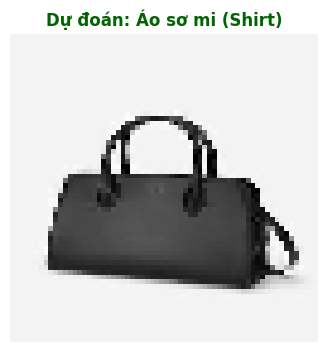

In [ ]:
# 1. Đọc tệp hình ảnh được chọn dưới dạng ảnh xám (Grayscale)
img_raw = cv2.imread(anh_kiem_tra_path, cv2.IMREAD_GRAYSCALE)
# 2. ĐÃ SỬA: Chuyển đổi (Resize) ảnh về chuẩn kích thước 64x64 pixel cho khớp với mô hình mới
img_resized = cv2.resize(img_raw, (64, 64))
# 3. [LƯU Ý ĐẢO MÀU NỀN]:
# Bộ dữ liệu Fashion MNIST chuẩn dùng nền ĐEN (giá trị 0) vật thể TRẮNG (giá trị 255).
# Nếu ảnh bạn chụp từ máy tính có nền sáng/trắng và vật thể tối màu,
# hãy xóa ký tự dấu '#' ở dòng dưới để thực hiện đảo màu giúp mô hình nhận diện đúng:
# img_resized = cv2.bitwise_not(img_resized)

# 4. Chuẩn hóa giá trị các điểm ảnh (pixel) về vùng dữ liệu [0, 1]
img_normalized = img_resized / 255.0

# 5. ĐÃ SỬA: Duỗi phẳng ảnh ma trận (64, 64) thành mảng 1D gồm 4096 phần tử (64 * 64 = 4096)
img_final = img_normalized.reshape(1, 4096)

# 6. Đưa dữ liệu ảnh vào mô hình ANN đã huấn luyện để dự báo (Bây giờ sẽ chạy mượt mà)
du_doan = fashion_model.predict(img_final)

# 7. Tìm vị trí chỉ số (index) có xác suất kết quả đầu ra cao nhất
chi_so_nhãn = np.argmax(du_doan)
ten_nhan_tieng_viet = class_names[chi_so_nhãn]

# 8. Hiển thị hình ảnh phóng to sau khi xử lý kèm tên phân loại dự đoán
plt.figure(figsize=(4, 4))
plt.imshow(img_resized, cmap='gray')
plt.title(f"Dự đoán: {ten_nhan_tieng_viet}", fontsize=12, color='darkgreen', fontweight='bold')
plt.axis('off')
plt.show()